Next word prediction using neural networks.

Overview

This notebook builds a Next Word Prediction model using LSTM (Long Short-Term Memory) neural networks. Given a sequence of words, the model predicts the most likely next word.

Workflow
1. Load and explore text data
2. Tokenize and preprocess
3. Create input/output sequences
4. Pad sequences
5. Build and train LSTM model
6. Predict next word

Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

Uploading small dataset to train the model.

In [2]:
text="""To be or not to be that is the question
Whether tis nobler in the mind to suffer
The slings and arrows of outrageous fortune
Or to take arms against a sea of troubles
And by opposing end them to die to sleep
No more and by a sleep to say we end"""

Tokenization-Convert words to numbers so the model can process them.

In [3]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts([text])

vocab_Size=len(tokenizer.word_index)+1
print(vocab_Size)


37


Create Input Sequences:
Break text into input/output training pairs.

In [4]:
input_seq=[]
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_seq.append(n_gram_sequence)

print("Total sequences:", len(input_seq))
print("First 5 sequences:", input_seq[:-1])

Total sequences: 47
First 5 sequences: [[1, 4], [1, 4, 5], [1, 4, 5, 11], [1, 4, 5, 11, 1], [1, 4, 5, 11, 1, 4], [1, 4, 5, 11, 1, 4, 12], [1, 4, 5, 11, 1, 4, 12, 13], [1, 4, 5, 11, 1, 4, 12, 13, 2], [1, 4, 5, 11, 1, 4, 12, 13, 2, 14], [15, 16], [15, 16, 17], [15, 16, 17, 18], [15, 16, 17, 18, 2], [15, 16, 17, 18, 2, 19], [15, 16, 17, 18, 2, 19, 1], [15, 16, 17, 18, 2, 19, 1, 20], [2, 21], [2, 21, 3], [2, 21, 3, 22], [2, 21, 3, 22, 6], [2, 21, 3, 22, 6, 23], [2, 21, 3, 22, 6, 23, 24], [5, 1], [5, 1, 25], [5, 1, 25, 26], [5, 1, 25, 26, 27], [5, 1, 25, 26, 27, 7], [5, 1, 25, 26, 27, 7, 28], [5, 1, 25, 26, 27, 7, 28, 6], [5, 1, 25, 26, 27, 7, 28, 6, 29], [3, 8], [3, 8, 30], [3, 8, 30, 9], [3, 8, 30, 9, 31], [3, 8, 30, 9, 31, 1], [3, 8, 30, 9, 31, 1, 32], [3, 8, 30, 9, 31, 1, 32, 1], [3, 8, 30, 9, 31, 1, 32, 1, 10], [33, 34], [33, 34, 3], [33, 34, 3, 8], [33, 34, 3, 8, 7], [33, 34, 3, 8, 7, 10], [33, 34, 3, 8, 7, 10, 1], [33, 34, 3, 8, 7, 10, 1, 35], [33, 34, 3, 8, 7, 10, 1, 35, 36]]


Pad Sequences:
Make all sequences the same length by padding with zeros at the beginning.

In [5]:
max_sequence_len = max([len(x) for x in input_seq])
print("Max sequence length:", max_sequence_len)

input_sequences = np.array(pad_sequences(input_seq,maxlen=max_sequence_len,padding='pre'))

print("Shape after padding:", input_sequences.shape)
print("First sequence:", input_sequences[0])
print("Last sequence:", input_sequences[-1])

Max sequence length: 10
Shape after padding: (47, 10)
First sequence: [0 0 0 0 0 0 0 0 1 4]
Last sequence: [33 34  3  8  7 10  1 35 36  9]


Create Features and Labels:
Split sequences into X (input) and y (output).

In [6]:
X=input_sequences[:,:-1]
Y=input_sequences[:,-1]

print("X shape:", X.shape)
print("y shape:", Y.shape)
print("First X:", X[0])
print("First y:", Y[0])

X shape: (47, 9)
y shape: (47,)
First X: [0 0 0 0 0 0 0 0 1]
First y: 4


One-Hot Encode the Labels:
Convert y from a single number to a probability
vector across the entire vocabulary.

In [7]:
y = to_categorical(Y, num_classes=vocab_Size)
print("y shape after encoding:", y.shape)
print("First y:", y[0])

y shape after encoding: (47, 37)
First y: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Building the LSTM Model

In [8]:
model = Sequential()
model.add(Embedding(vocab_Size, 10, input_length=max_sequence_len-1))
model.add(LSTM(150))
model.add(Dense(vocab_Size, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training the Model:
200 epochs,~89% accuracy achieved.

In [9]:
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0638 - loss: 3.6113
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1277 - loss: 3.6067
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1277 - loss: 3.6027
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1277 - loss: 3.5977
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1277 - loss: 3.5916 
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1277 - loss: 3.5847
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1277 - loss: 3.5751
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1277 - loss: 3.5594
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1277 - loss: 3.5413
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1277 - loss: 3.5118
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1277 - loss: 3.4705
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1277 - l

Predict the Next Word

In [10]:
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list],
                                maxlen=max_sequence_len-1,
                                padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)

    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word

print(predict_next_word(model, tokenizer, "to be or not", max_sequence_len))
print(predict_next_word(model, tokenizer, "the slings and", max_sequence_len))
print(predict_next_word(model, tokenizer, "to take arms", max_sequence_len))

to
arrows
arms


Plot Training Accuracy & Loss

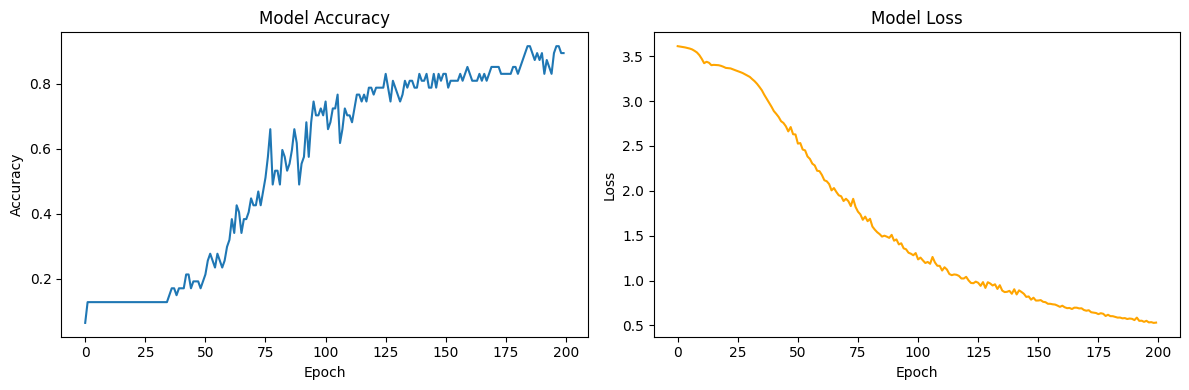

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

ax2.plot(history.history['loss'], color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.show()

Conclusion:
Built a Next Word Prediction model using LSTM. Achieved 89% accuracy on Shakespeare text corpus.